# EDA

# EDA = Exploratory Data Analysis



In [8]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [9]:
df = pd.read_csv('titanic_data_updated.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.shape

(891, 12)

total 891 data and 12 columns (will be used as feature)

In [11]:
# randomly shuffle the data and see the features and target variable

df.sample(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
629,630,no,third,"O'Connell, Mr. Patrick D",male,NaN,0,0,334912,7.7333,NaN,Q
57,58,no,third,"Novel, Mr. Mansouer",male,28.5,0,0,2697,7.2292,NaN,C
382,383,no,third,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
207,208,yes,third,"Albimona, Mr. Nassef Cassem",male,26.0,0,0,2699,18.7875,NaN,C
653,654,yes,third,"O'Leary, Miss. Hanora ""Norah""",female,NaN,0,0,330919,7.8292,NaN,Q


here some null values are found by running the above multiple times

# Input screening

In [13]:
# see the missing values

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
# checking duplicates

df.duplicated().sum()

np.int64(0)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [16]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


#### Univarient analysis
- ekta column ke dhore analysis kora

<Axes: xlabel='Survived', ylabel='count'>

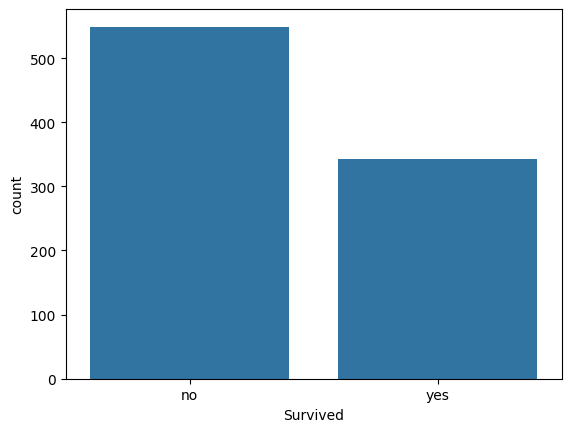

In [ ]:
# for survived column
sns.countplot(x='Survived', data=df)

survival er rate imbalanced. no onek beshi

In [18]:
df['Survived'].value_counts()

Survived
no     549
yes    342
Name: count, dtype: int64

In [19]:
# to see the percentage of survived and not survived

df['Survived'].value_counts(normalize=True)

Survived
no     0.616162
yes    0.383838
Name: proportion, dtype: float64

([<matplotlib.patches.Wedge at 0x12f10e29d30>,
 [Text(-0.39257494735793463, 1.0275626067091557, 'no'),
  Text(0.3925749146953058, -1.0275626191877425, 'yes')],
 [Text(-0.21413178946796432, 0.5604886945686304, '61.6%'),
  Text(0.21413177165198496, -0.5604887013751322, '38.4%')])

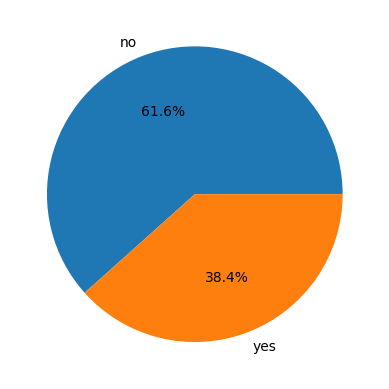

In [23]:
import matplotlib.pyplot as plt
survived_count = df['Survived'].value_counts()
plt.pie(survived_count, labels=survived_count.index, autopct='%1.1f%%')

<Axes: xlabel='Pclass', ylabel='count'>

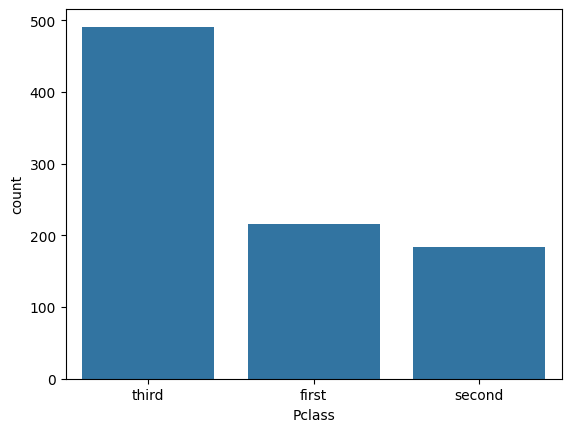

In [24]:
sns.countplot(data=df, x=df['Pclass'])

([<matplotlib.patches.Wedge at 0x12f112bad20>,
 [Text(-0.17571619097547903, 1.085874679799225, 'third'),
  Text(-0.5160760536623383, -0.9714244730478574, 'first'),
  Text(0.8765111790709129, -0.6646263258130227, 'second')],
 [Text(-0.09584519507753402, 0.5922952798904862, '55.1%'),
  Text(-0.2814960292703663, -0.5298678943897404, '24.2%'),
  Text(0.47809700676595246, -0.3625234504434669, '20.7%')])

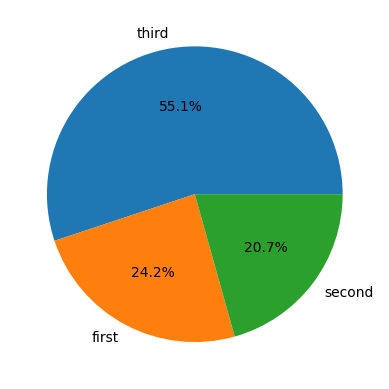

In [28]:
val_count = df['Pclass'].value_counts()

plt.pie(val_count,labels=val_count.index, autopct='%1.1f%%')

In [30]:
df['Pclass'].value_counts(normalize=True)

Pclass
third     0.551066
first     0.242424
second    0.206510
Name: proportion, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

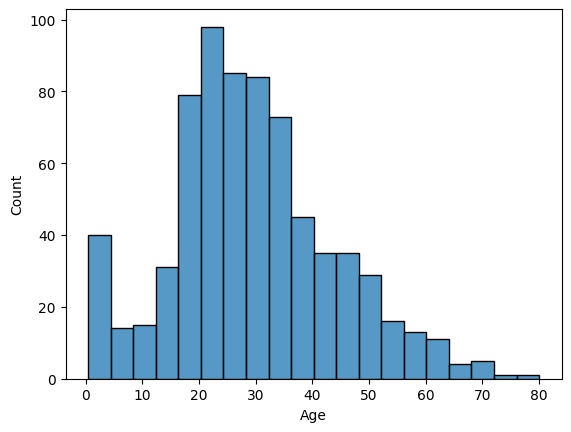

In [32]:
# univarient analysis for numerical columns
sns.histplot(data=df, x='Age', bins=20)

<Axes: xlabel='Age', ylabel='Density'>

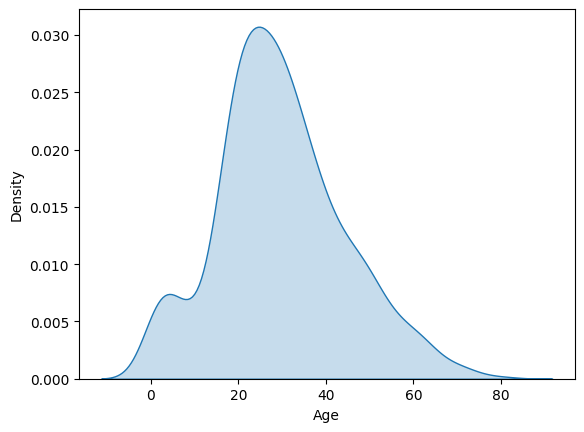

In [33]:
sns.kdeplot(data=df, x="Age", fill=True)


<Axes: xlabel='Fare', ylabel='Count'>

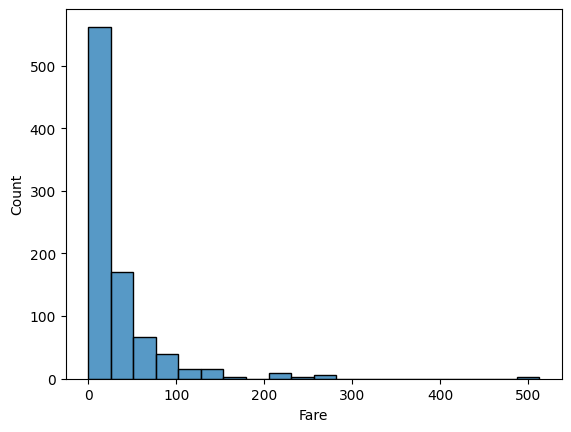

In [36]:
sns.histplot(data=df, x='Fare', bins=20)

C:\Users\User\AppData\Local\Temp\ipykernel_19020\1785776946.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='Fare', shade=True)


<Axes: xlabel='Fare', ylabel='Density'>

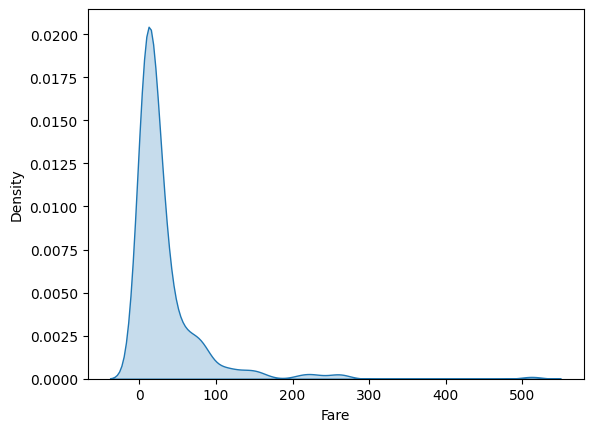

In [37]:
sns.kdeplot(data=df, x='Fare', shade=True)

<Axes: ylabel='Fare'>

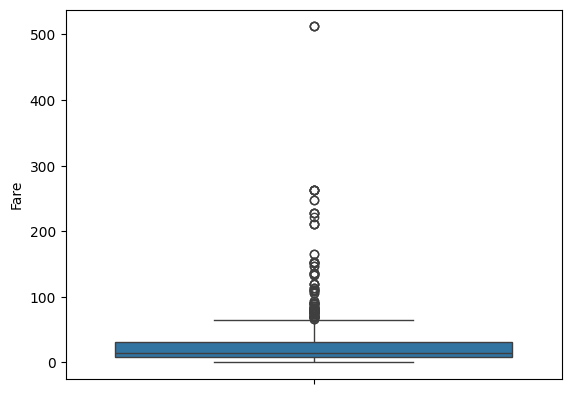

In [39]:
sns.boxplot(df['Fare'])